In [1]:
# ===============================================
# 1. 이진분류 모델 실습
# ===============================================

In [2]:
import tensorflow as tf

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_breast_cancer          # 암진단 데이터 
import joblib                                             

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout      # 딥러닝 레이어 구성 및 드롭아웃 
from tensorflow.keras.callbacks import EarlyStopping    # 학습 조기종료 콜백 함수

In [34]:
# 데이터 읽어오기
data = load_breast_cancer()
X = data.data
y = data.target

feature_names = data.feature_names    # 특성 이름
df = pd.DataFrame(X, columns=feature_names)

df['target'] = y
print("전체 데이터 shape:", df.shape)

전체 데이터 shape: (569, 31)


In [21]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [35]:
# 학습용/테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
# 딥러닝 모델 정의
model = Sequential()     # 순차형 신경망 모델 생성
model.add(Dense(64, activation='relu', input_shape=(X_test_scaled.shape[1],)))  # 첫번째 은닉층 추가
model.add(Dropout(0.2))   # 과적합 방지를 위해 드롭아웃 20% 적용

model.add(Dense(32, activation='relu'))  # 두 번째 은닉층 추가  
model.add(Dropout(0.2))   # 과적합 방지를 위해 드롭아웃 20% 적용

model.add(Dense(1, activation='sigmoid'))   # 출력층 추가  --> 이진 분류이므로 출력층 노드 1개와 sigmoid 활성화 함수 사용

model.summary()

D:\anaconda3\envs\youn\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [40]:
# 모델 학습
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7005 - loss: 0.6555 - val_accuracy: 0.9341 - val_loss: 0.4305
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9176 - loss: 0.3644 - val_accuracy: 0.9451 - val_loss: 0.2790
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9451 - loss: 0.2428 - val_accuracy: 0.9560 - val_loss: 0.1999
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9560 - loss: 0.1913 - val_accuracy: 0.9560 - val_loss: 0.1579
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9588 - loss: 0.1580 - val_accuracy: 0.9670 - val_loss: 0.1316
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9615 - loss: 0.1305 - val_accuracy: 0.9670 - val_loss: 0.1130
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9725 - loss: 0.1127 - val_accuracy: 0.9780 - val_loss: 0.0989
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1180 - val_accuracy: 0.9780 - 

In [41]:
# 모델 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print("테스트 손실 : ", test_loss)
print("테스트 정확도 : ", test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

# 확률을 0 또는 1 클래스로 변환
y_pred = (y_prob >= 0.5).astype(int).flatten()

# 정확도 계산
acc = accuracy_score(y_test, y_pred)


# confusion matrix 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print("정확도 : ", acc)
print("confusion matrix : \n", cm)
print("분류 리포트 : \n", classification_report(y_test, y_pred))




테스트 손실 :  0.13052451610565186
테스트 정확도 :  0.9649122953414917


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002AAA15A65F0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
정확도 :  0.9649122807017544
confusion matrix : 
 [[41  1]
 [ 3 69]]
분류 리포트 : 
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [42]:
# 학습 결과 저장 (모델을 파일로 저장)

# 파일 저장
model.save('Binary_Classification.h5')

# 학습이력 데이터 프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습 이력 csv로 저장
history_df.to_csv('Binary_Classification.csv', index=False)

print(' 모델 및 학습 이력 저장 완료')

 모델 및 학습 이력 저장 완료


In [43]:
# 저장 결과 읽어오기
loaded_model = tf.keras.models.load_model('Binary_Classification.h5')


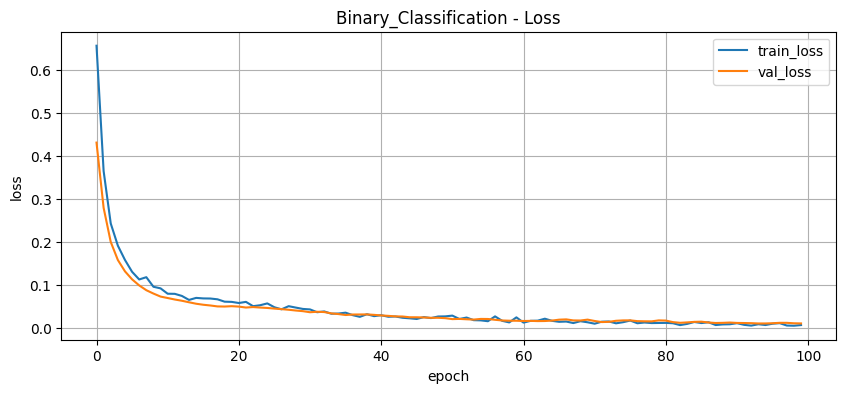

In [44]:
# 모델 성능 확인
# loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Binary_Classification - Loss')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

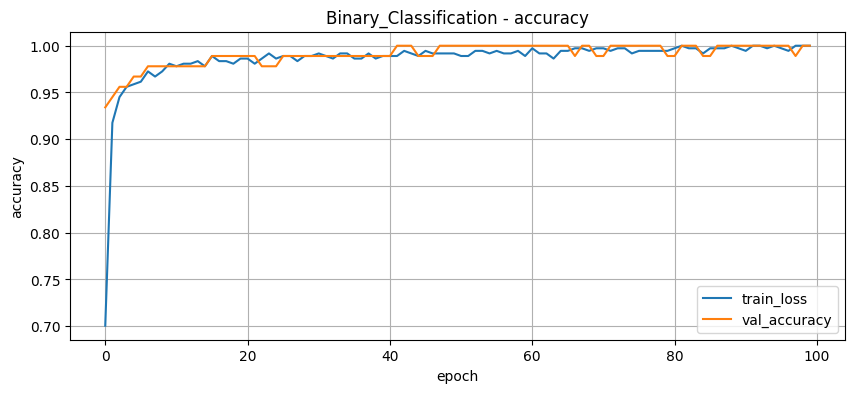

In [45]:
# 모델 성능 확인
# accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_loss')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Binary_Classification - accuracy')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

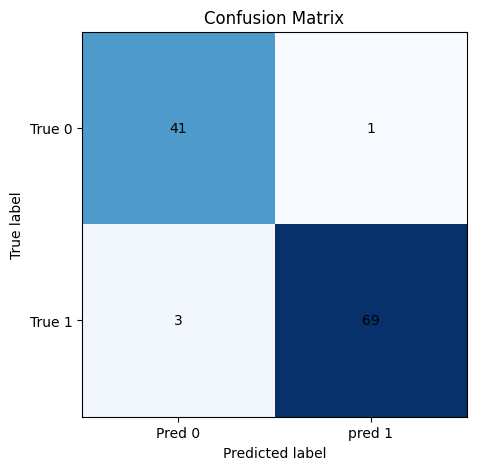

In [49]:
# confusion matrix 시각화
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')

# x축과 y축 눈금 설정
plt.xticks([0,1], ['Pred 0', 'pred 1'])
plt.yticks([0,1], ['True 0', 'True 1'])

# CM 내부에 숫자 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [51]:
joblib.dump(scaler, 'Binary_Classification.pkl')

['Binary_Classification.pkl']

In [52]:
# 신규 데이터 예측 (추론)

new_data = X_test[:5]

loaded_scaler = joblib.load('Binary_Classification.pkl')

new_data_scaled = loaded_scaler.transform(new_data)

new_prob = loaded_model.predict(new_data_scaled)

new_pred = (new_prob >= 0.5).astype(int).flatten()

for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측확률: {new_prob[i][0]:.4f}, 예측클래스: {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1번 샘플 - 예측확률: 0.0000, 예측클래스: 0
2번 샘플 - 예측확률: 1.0000, 예측클래스: 1
3번 샘플 - 예측확률: 0.0000, 예측클래스: 0
4번 샘플 - 예측확률: 0.1138, 예측클래스: 0
5번 샘플 - 예측확률: 0.0000, 예측클래스: 0
